In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time
from sklearn.metrics import confusion_matrix
from sklearn . metrics import ConfusionMatrixDisplay

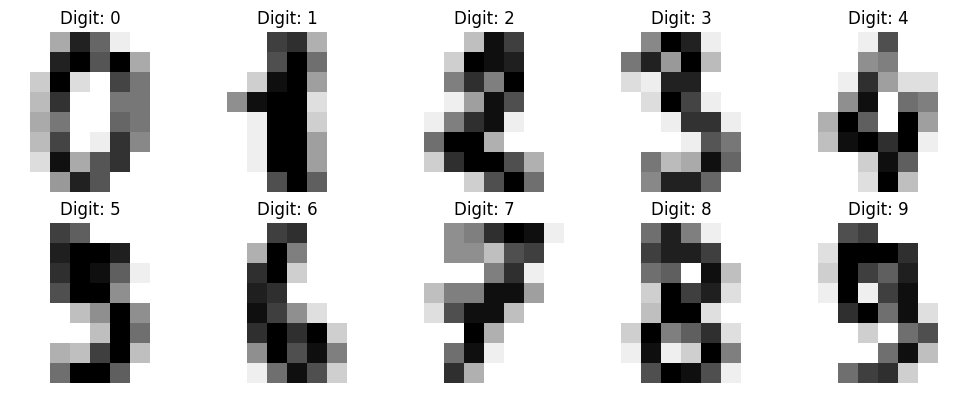

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
digits = load_digits( as_frame=False)

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Digit: {digits.target[i]}")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

print(digits.DESCR)

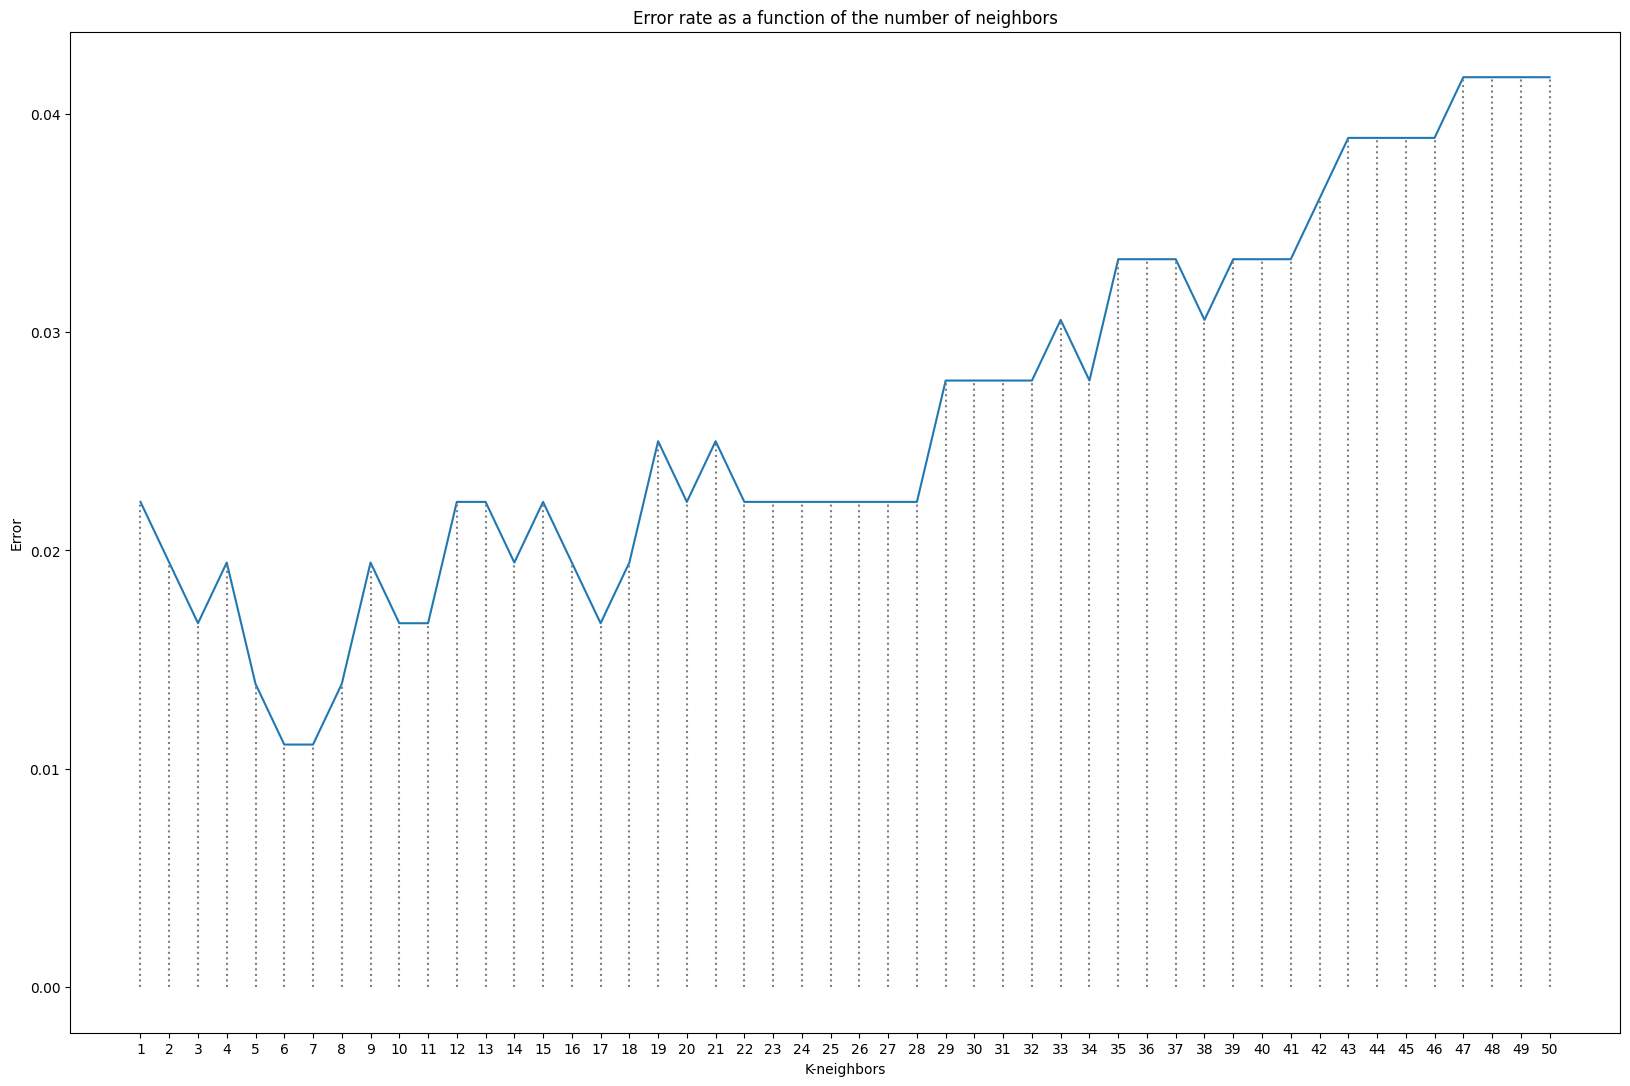

optimal k = 6
error = 0.011111


In [3]:
K=[0] * 50
optimal_k=0
optimal_error=1
for i,k in enumerate(K):
    knn = KNeighborsClassifier(n_neighbors=i+1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    K[i]=(1-accuracy)
    if K[i]<optimal_error:
        optimal_error= K[i]
        optimal_k=i+1
    
plt.figure(figsize =(20,13))
plt.plot(np.arange(1,51,1), K)
plt.xticks(np.arange(1,51,1))
plt.vlines(np.arange(1,51,1),0, K, linestyle="dotted", color="gray")
plt.xlabel("K-neighbors")
plt.ylabel("Error")
plt.title("Error rate as a function of the number of neighbors")
plt.show()

knn_error=K[optimal_k-1]

print("optimal k =",optimal_k)
print(f"error = {knn_error:.6f}" )

In [4]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=10000)

lr . fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
lr_error=(1-accuracy)


print(f"error = {lr_error:.6f}" )

error = 0.025000


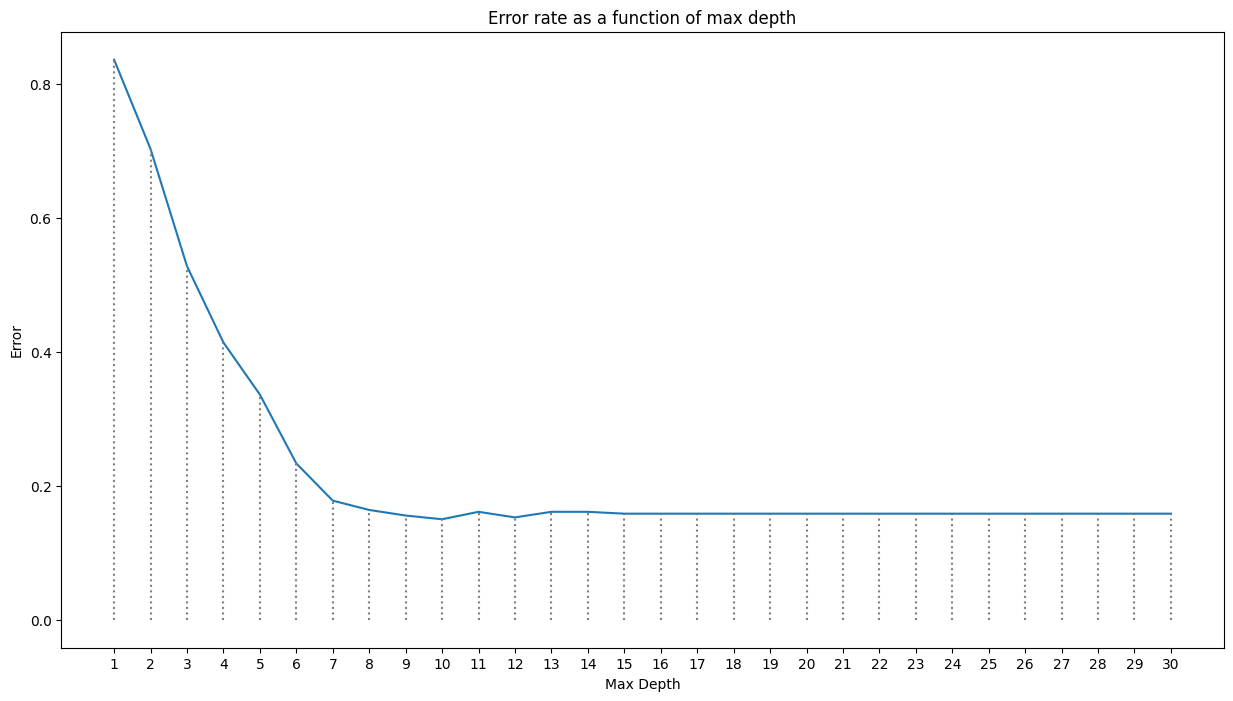

optimal depth = 10
error = 0.150000


In [5]:
from sklearn.tree import DecisionTreeClassifier


K=[0] * 30
optimal_depth=0
optimal_error=1
for i,k in enumerate(K):
    dt = DecisionTreeClassifier(criterion='gini', random_state=42,max_depth=i+1)
    dt.fit(X_train,y_train)
    y_pred = dt.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    K[i]=(1-accuracy)
    if K[i]<optimal_error:
        optimal_error= K[i]
        optimal_depth=i+1
    
plt.figure(figsize =(15,8))
plt.plot(np.arange(1,31,1), K)
plt.xticks(np.arange(1,31,1))
plt.vlines(np.arange(1,31,1),0, K, linestyle="dotted", color="gray")
plt.xlabel("Max Depth")
plt.ylabel("Error")
plt.title("Error rate as a function of max depth")
plt.show()

dt_error=K[optimal_depth-1]

print("optimal depth =",optimal_depth)
print(f"error = {dt_error:.6f}" )


# Comparisons:


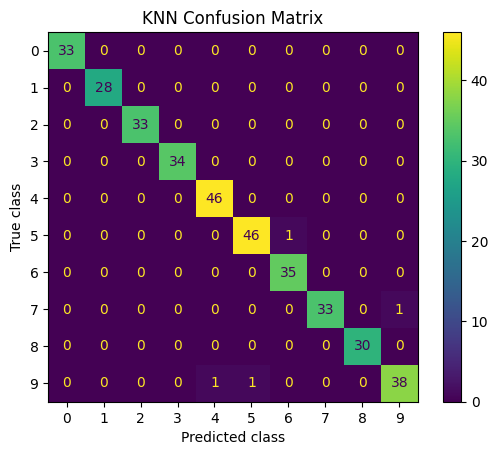

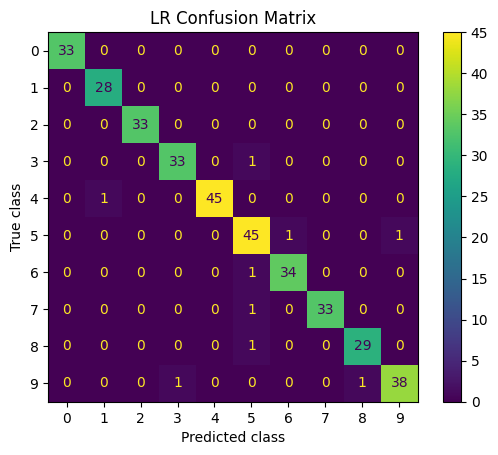

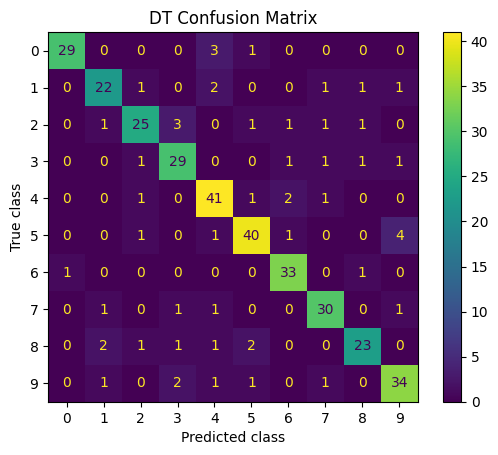

In [6]:
###################### Knn ######################

knn = KNeighborsClassifier(n_neighbors=optimal_k)

start_time = time.time()
knn.fit(X_train, y_train)
end_time = time.time()
training_duration_knn = end_time - start_time

start_time = time.time()
y_pred=knn.predict(X_test)
end_time = time.time()
prediction_time_knn = end_time - start_time
cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm ,display_labels=digits.target_names )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("KNN Confusion Matrix")
plt .show()

###################### LR ######################

lr = LogisticRegression(random_state=42, max_iter=10000)

start_time = time.time()
lr . fit(X_train, y_train)
end_time = time.time()
training_duration_lr = end_time - start_time

start_time = time.time()
y_pred = lr.predict(X_test)
end_time = time.time()
prediction_time_lr = end_time - start_time

cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm ,display_labels=digits.target_names )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("LR Confusion Matrix")
plt .show()

###################### TREE ######################
dt = DecisionTreeClassifier(criterion='gini', random_state=42,max_depth=optimal_depth)

start_time = time.time()
dt . fit(X_train, y_train)
end_time = time.time()
training_duration_dt = end_time - start_time

start_time = time.time()
y_pred = dt.predict(X_test)
end_time = time.time()
prediction_time_dt = end_time - start_time

cm = confusion_matrix(y_test, y_pred)
display=ConfusionMatrixDisplay ( confusion_matrix=cm ,display_labels=digits.target_names )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("DT Confusion Matrix")
plt .show()


The accuracy scores and confusion matrixes show that for this dataset Knn is best followed by logistic regression and then by decision trees.

In [7]:
print("Comparisons:")
print("-"*50)
print("Test set error :")
print(f"KNN: {knn_error:.4f}")
print(f"Log Reg: {lr_error:.4f}")
print(f"D-Tree: {dt_error:.4f}")
print("-"*50)
print("Training time :")
print(f"KNN: {training_duration_knn:.4f}")
print(f"Log Reg: {training_duration_lr:.4f}")
print(f"D-Tree: {training_duration_dt:.4f}")
print("-"*50)
print("Prediction time:")
print(f"KNN: {prediction_time_knn:.4f}")
print(f"Log Reg: {prediction_time_lr:.4f}")
print(f"D-Tree: {prediction_time_dt:.4f}")
print("-"*50)

Comparisons:
--------------------------------------------------
Test set error :
KNN: 0.0111
Log Reg: 0.0250
D-Tree: 0.1500
--------------------------------------------------
Training time :
KNN: 0.0026
Log Reg: 1.5139
D-Tree: 0.0362
--------------------------------------------------
Prediction time:
KNN: 0.0077
Log Reg: 0.0009
D-Tree: 0.0006
--------------------------------------------------


## Conslusions:
- Knn is the best fit model for this task as it has the best accuracy without sacrificing much training and testing time, this is only true because of the size of the dataset and its relatively low dimentionality.
- single Decision trees are not good for classifying images as they are prone to either missing subtelties in the data (it doesnt work well with pixels instead of image features like colors) or to overfitting (if we extend the depth to make up for the previous point)
- logistic regression is a linear model that struggles with high-dimensional pixel data, leading to poor performance. However, it can work for simple tasks (like handwritten digits after feature engineering), but it often overfits and ignores crucial spatial patterns.

- all 3 models are not generally used for image classification but out of the three knn is the best fit.